In [26]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [27]:
train_data = pd.read_csv("data/mnist_train.csv", header=None)
test_data = pd.read_csv("data/mnist_test.csv", header=None)
train_data = np.array(train_data) # matrix of 60000 (samples) x 785 (features + 1 label) entries
test_data = np.array(test_data) # matrix of 60000 (samples) x 785 (features + 1 label) entries

In [28]:
np.random.shuffle(train_data)
m, n = train_data.shape # m = 60000, n = 785
data_train = train_data.T # we get a matrix of 785 rows and 1000 columns where the first row has labels, all other row has pixel values and each column is one sample

# data_train = data[1000:m].T # matrix of 785 rows and 59000 columns
Y_train = data_train[0] # vector of 59000 values
X_train = data_train[1:n] # matrix of 785 rows and 59000 columns
X_train = X_train/255.0

data_test = test_data.T
Y_test = data_test[0] # target values, first row
X_test = data_test[1:n] # all rows except the first one
X_test = X_test/255



In [29]:
def init_params():
    W1 = np.random.rand(512, 784) - 0.5
    b1 = np.random.rand(512, 1) - 0.5
    W2 = np.random.rand(512, 512) - 0.5
    b2 = np.random.rand(512, 1) - 0.5
    W3 = np.random.rand(10, 512) - 0.5
    b3 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2, W3, b3

def ReLU(z):
    return np.maximum(0, z)

def deriv_ReLU(z):
    return z > 0

def softmax(z):
    prob = np.exp(z)/sum(np.exp(z))
    return prob

def forward_prop(W1, b1, W2, b2, W3, b3, X):
    z1 = W1.dot(X) + b1
    A1 = ReLU(z1)
    z2 = W2.dot(A1) + b2
    A2 = ReLU(z2)
    z3 = W3.dot(A2) + b3
    A3 = softmax(z3)
    return z1, A1, z2, A2, z3, A3

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def back_prop(z1, A1, z2, A2, z3, A3, W1, W2, W3, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dz3 = A3 - one_hot_Y
    dW3 = 1/ m * dz3.dot(A2.T)
    db3 = 1/ m*np.sum(dz3, axis = 1, keepdims=True)

    dz2 = W3.T.dot(dz3)*deriv_ReLU(z2)
    dW2 = 1/ m * dz2.dot(A1.T)
    db2 = 1/ m*np.sum(dz2, axis = 1, keepdims=True)

    dz1 = W2.T.dot(dz2)*deriv_ReLU(z1)
    dW1 = 1/ m * dz1.dot(X.T)
    db1 = 1/ m*np.sum(dz1, axis = 1, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

def update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha):
    W1 = W1 - alpha*dW1
    b1 = b1 - alpha*db1
    W2 = W2 - alpha*dW2
    b2 = b2 - alpha*db2
    W3 = W3 - alpha*dW3
    b3 = b3 - alpha*db3
    return W1, b1, W2, b2, W3, b3

In [30]:
def get_predictions(A3):
    return np.argmax(A3, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, epochs, alpha, batch_size):
    W1, b1, W2, b2, W3, b3 = init_params()
    for i in range(epochs):
        # shuffling the data
        perm = np.random.permutation(X.shape[1])
        X_shuffled = X[:, perm]
        Y_shuffled = Y[perm]

        # mini-batches
        for start in range(0, X.shape[1], batch_size):
            end = start + batch_size
            X_batch = X_shuffled[:, start:end]
            Y_batch = Y_shuffled[start:end]
            z1, A1, z2, A2, z3, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X_batch)
            dW1, db1, dW2, db2, dW3, db3 = back_prop(z1, A1, z2, A2, z3, A3, W1, W2, W3, X_batch, Y_batch)
            W1, b1, W2, b2, W3, b3 = update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha)
            # print("Param W1:" , np.linalg.norm(W1))
            # print("Param W1:" , np.linalg.norm(W2))
            if i % 10 != 0:
                predictions = get_predictions(A3)
                accuracy = get_accuracy(predictions, Y_batch)
                print(
                    f"Epoch {i+1} | "
                    f"Batch {start // batch_size + 1} | "
                    f"Accuracy: {accuracy * 100:.2f}%"
                )
        
    return W1, b1, W2, b2, W3, b3

In [31]:
batch_size = 10
epochs = 5
lr = 0.001

In [32]:
W1, b1, W2, b2, W3, b3 = gradient_descent(X_train, Y_train, epochs, lr, batch_size)

# saving the model

import os

os.makedirs("models", exist_ok=True)

np.savez(
    "models/scratch_mnist.npz",
    W1=W1,
    b1=b1,
    W2=W2,
    b2=b2,
    W3=W3,
    b3=b3
)

Epoch 2 | Batch 1 | Accuracy: 100.00%
Epoch 2 | Batch 2 | Accuracy: 90.00%
Epoch 2 | Batch 3 | Accuracy: 100.00%
Epoch 2 | Batch 4 | Accuracy: 90.00%
Epoch 2 | Batch 5 | Accuracy: 100.00%
Epoch 2 | Batch 6 | Accuracy: 100.00%
Epoch 2 | Batch 7 | Accuracy: 100.00%
Epoch 2 | Batch 8 | Accuracy: 90.00%
Epoch 2 | Batch 9 | Accuracy: 90.00%
Epoch 2 | Batch 10 | Accuracy: 100.00%
Epoch 2 | Batch 11 | Accuracy: 90.00%
Epoch 2 | Batch 12 | Accuracy: 100.00%
Epoch 2 | Batch 13 | Accuracy: 90.00%
Epoch 2 | Batch 14 | Accuracy: 70.00%
Epoch 2 | Batch 15 | Accuracy: 100.00%
Epoch 2 | Batch 16 | Accuracy: 90.00%
Epoch 2 | Batch 17 | Accuracy: 80.00%
Epoch 2 | Batch 18 | Accuracy: 100.00%
Epoch 2 | Batch 19 | Accuracy: 80.00%
Epoch 2 | Batch 20 | Accuracy: 100.00%
Epoch 2 | Batch 21 | Accuracy: 90.00%
Epoch 2 | Batch 22 | Accuracy: 80.00%
Epoch 2 | Batch 23 | Accuracy: 90.00%
Epoch 2 | Batch 24 | Accuracy: 100.00%
Epoch 2 | Batch 25 | Accuracy: 100.00%
Epoch 2 | Batch 26 | Accuracy: 100.00%
Epoch 2 

In [33]:
def make_predictions(X, W1, b1, W2, b2, W3, b3):
    _, _, _, _, _, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X)
    predictions = get_predictions(A3)
    return predictions

def test_prediction(index, W1, b1, W2, b2, W3, b3):
    current_image = X_train[:, index, None]
    predictions = make_predictions(current_image, W1, b1, W2, b2, W3, b3)
    label = Y_train[index]
    print("Predictions: ", predictions)
    print("Label: ", label)

    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Predictions:  [5]
Label:  5


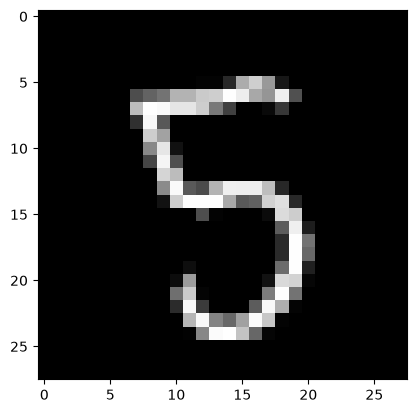

In [34]:
test_prediction(7482, W1, b1, W2, b2, W3, b3)

Predictions:  [8]
Label:  8


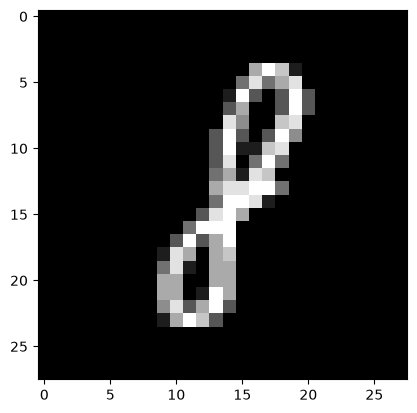

In [35]:
test_prediction(4829, W1, b1, W2, b2, W3, b3)


Predictions:  [2]
Label:  2


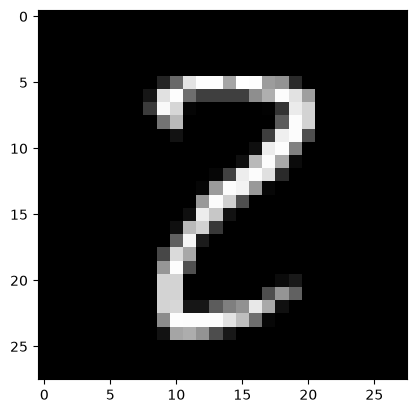

In [36]:
test_prediction(20, W1, b1, W2, b2, W3, b3)


Predictions:  [8]
Label:  8


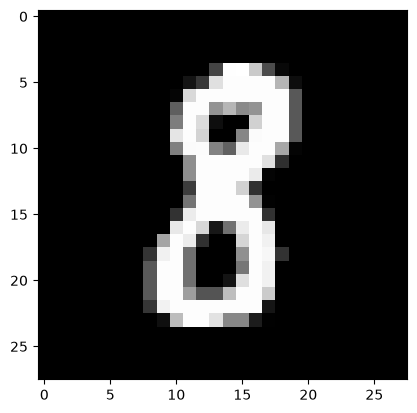

In [37]:
test_prediction(378, W1, b1, W2, b2, W3, b3)

In [38]:
test_predictions = make_predictions(X_test, W1, b1, W2, b2, W3, b3)
print("Test accuracy: ", get_accuracy(test_predictions, Y_test) * 100)

Test accuracy:  93.74
